# Script A — generation + MIA attack (5 seeds)

**Slow path, run once.** For each seed in {111, 222, 333, 444, 555} and each model: train the main generator, save synthetic trips, train shadow generators, run the membership inference attack, and save per-user MIA results + accuracy / F1 / AUC overall and per activity group.

**Precondition:** apply the `inverse_transform` patch in `src/feature_pipeline.py` so generated trips keep `hour` and `day_of_week` (Script B's temporal metric needs them).

Folder layout assumed:
```
UPF_Thesis/
  src/ ...                  (existing, one level up)
  data/od_trips_*.csv       (existing, one level up)
  v3/                       (this notebook runs here)
    01_generate_and_attack_v3.ipynb
    artifacts_v3/           (created here)
    outputs/                (logs, created here)
```

### 1. Setup — put the project root on the path

In [1]:
from google.colab import drive; drive.mount('/content/drive')
%cd /content/drive/MyDrive/UPF_Thesis/v4
import sys, os
sys.path.insert(0, os.getcwd())   # v4 -> `import src...` resolves to v4/src
print('cwd       :', os.getcwd())
print('src found :', os.path.isdir('src'))

import src, inspect
print('src loaded from:', os.path.dirname(inspect.getfile(src)))   # must end in /v4/src

Mounted at /content/drive
/content/drive/MyDrive/UPF_Thesis/v4
cwd       : /content/drive/MyDrive/UPF_Thesis/v4
src found : True
src loaded from: /content/drive/MyDrive/UPF_Thesis/v4/src


### 2. Imports

In [2]:
pip install h3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 25.1 MB/s eta 0:00:00


In [3]:
import copy
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import joblib
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

from src.feature_pipeline import ODFeaturePipeline
from src.models.wrappers import GeneratorWrapper
from src.models.vae import VAEModel
from src.models.wgan_gp import WGANModel
from src.models.bootstrap import BootstrapModel
from src.user_split import (
    load_and_filter_trip_data, build_user_summary, get_users_by_split,
    get_main_training_users, get_user_trips,
)
from src.attacks.shadow import (
    generate_shadow_splits, verify_shadow_labels,
    train_shadow_generators, verify_shadow_training_matches_labels,
)
from src.attacks.feature_table import build_feature_table
from src.attacks.attack_model import train_attack_model, run_attack_evaluation
from src.log_experiments import log_metrics

### 3. Config

In [4]:
# ----------------- paths (src + dataset live OUTSIDE this folder) -----------------
DATA_PATH     = 'od_trips_20260410_input.csv'   # <-- adjust if needed
ARTIFACT_ROOT = Path('artifacts_v4')                    # inside UPF_Thesis/v4/
MIA_LOG       = 'outputs/mia_log_v4.json'               # inside UPF_Thesis/v4/

SEEDS = [111, 222, 333, 444, 555]
N_SHADOW = 10 #20
SHADOW_TRAIN_FRAC = 0.5
TEST_SIZE = 0.2
SHADOW_SIZE = 0.5

MIA_FEATURE_COLS = [
    'min_od_distance', 'p01_od_distance', 'p05_od_distance', 'p25_od_distance',
    'median_od_distance', 'mean_od_distance', 'std_od_distance',
    'close_trip_rate', 'very_close_trip_rate',
    'duration_similarity', 'distance_similarity', 'od_overlap', 'n_target_trips',
]

# name -> (model_cls, model_params, train_params)
MODELS = {
    'VAE': (VAEModel,
            {'latent_dim': 8, 'lr': 1e-3, 'beta': 0.1},
            {'epochs': 80, 'batch_size': 64, 'val_size': 0.1, "kl_warmup_frac": 0.4, 'random_state': 0}),


    'WGAN_GP': (WGANModel,  # change to lower epoch if too slow
                {'noise_dim': 64, 'hidden_dim': 128, 'lr': 1e-4,
                 'lambda_gp': 10.0, 'critic_steps': 3},
                {'epochs': 100, 'batch_size': 64, 'val_size': 0.1, 'random_state': 0}),

    'Bootstrap': (BootstrapModel,
                  {'random_state': 0},
                  {'batch_size': 64}),
}

In [5]:
df = load_and_filter_trip_data(DATA_PATH)
df.head()

Removed rows: 30
Percent removed: 0.39


### 4. Smoke-test toggle
Run this once with `SMOKE = True`, verify artefacts, then flip to `False`.

In [ ]:
# ----------------- SMOKE TEST toggle -----------------
SMOKE = False

if SMOKE:
    SEEDS_RUN  = [111]
    MODELS_RUN = {'WGAN_GP': MODELS['WGAN_GP']}
    N_SHADOW   = 3
else:
    SEEDS_RUN  = SEEDS
    MODELS_RUN = MODELS
print('seeds :', SEEDS_RUN)
print('models:', list(MODELS_RUN))
print('shadows per model:', N_SHADOW)

seeds : [111, 222, 333, 444, 555]
models: ['VAE', 'WGAN_GP', 'Bootstrap']
shadows per model: 10


### 5. Helpers

In [6]:
def _json_safe(obj):
    if isinstance(obj, dict):
        return {k: _json_safe(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_json_safe(v) for v in obj]
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, float) and np.isnan(obj):
        return None
    return obj


def mia_overall_and_by_group(mia_df, group_col='activity_group'):
    y, pred, p = mia_df['ground_truth'], mia_df['prediction'], mia_df['membership_probability']
    overall = {
        'mia_accuracy': float(accuracy_score(y, pred)),
        'mia_f1': float(f1_score(y, pred, zero_division=0)),
        'mia_auc': float(roc_auc_score(y, p)) if y.nunique() > 1 else np.nan,
        'n_eval_users': int(len(mia_df)),
        'n_in': int(y.sum()), 'n_out': int((1 - y).sum()),
    }
    rows = []
    for g, sub in mia_df.groupby(group_col, observed=True):
        yy, pp, prob = sub['ground_truth'], sub['prediction'], sub['membership_probability']
        rows.append({
            'activity_group': str(g), 'n': int(len(sub)),
            'n_in': int(yy.sum()), 'n_out': int((1 - yy).sum()),
            'accuracy': float(accuracy_score(yy, pp)),
            'f1': float(f1_score(yy, pp, zero_division=0)) if yy.nunique() > 1 else np.nan,
            'auc': float(roc_auc_score(yy, prob)) if yy.nunique() > 1 else np.nan,
            'attack_advantage': float(accuracy_score(yy, pp) - 0.5),
        })
    return overall, pd.DataFrame(rows)


def seeded_params(model_params, train_params, seed):
    """Override random_state only where the model already keeps it (VAE/WGAN ->
    train_params, Bootstrap -> model_params), matching the v2 convention."""
    mp, tp = copy.deepcopy(model_params), copy.deepcopy(train_params)
    if 'random_state' in mp:
        mp['random_state'] = seed
    if 'random_state' in tp:
        tp['random_state'] = seed
    return mp, tp

### 6. Per-seed routine

In [7]:



def run_seed(df, seed):
    print('\n' + '#' * 70 + f'\n# SEED {seed}\n' + '#' * 70)
    np.random.seed(seed); torch.manual_seed(seed)
    #vae_tp  = {**vae_train_params,  "random_state": seed}   # update
    #wgan_tp = {**wgan_train_params, "random_state": seed}

    user_summary = build_user_summary(
        df, user_col='user_id', duration_col='duration_minutes',
        distance_col='centroid_dist',
        test_size=TEST_SIZE, shadow_size=SHADOW_SIZE, random_state=seed,
    )
    main_train_df = get_user_trips(df, get_main_training_users(user_summary))
    shadow_users   = get_users_by_split(user_summary, 'shadow')
    eval_in_users  = get_users_by_split(user_summary, 'eval_in')
    eval_out_users = get_users_by_split(user_summary, 'eval_out')
    eval_users = eval_in_users + eval_out_users

    eval_user_trips   = {u: get_user_trips(df, u) for u in eval_users}
    shadow_user_trips = {u: get_user_trips(df, u) for u in shadow_users}
    ground_truth_labels = {u: 1 for u in eval_in_users}
    ground_truth_labels.update({u: 0 for u in eval_out_users})

    pipeline = ODFeaturePipeline(); pipeline.fit(main_train_df)

    split_dir = ARTIFACT_ROOT / 'splits'; split_dir.mkdir(parents=True, exist_ok=True)
    user_summary.to_csv(split_dir / f'user_summary_seed{seed}.csv', index=False)

    shadow_labels = generate_shadow_splits(
        shadow_users, n_shadow=N_SHADOW, train_frac=SHADOW_TRAIN_FRAC, random_state=seed)
    verify_shadow_labels(shadow_labels, shadow_users)

    for model_name, (model_cls, model_params, train_params) in MODELS_RUN.items():
        print(f'\n--- {model_name} | seed {seed} ---')
        mp, tp = seeded_params(model_params, train_params, seed)
        out_dir = ARTIFACT_ROOT / model_name; out_dir.mkdir(parents=True, exist_ok=True)
        base = out_dir / f'{model_name.lower()}_seed{seed}'

        main_gen = GeneratorWrapper(model_cls, mp, tp, pipeline)
        main_gen.fit(main_train_df)
        synth_df = main_gen.generate(len(main_train_df))
        synth_df.to_csv(f'{base}.csv', index=False)
        print(f'  synth rows: {len(synth_df)} -> {base}.csv')

        shadow_synth, shadow_log = train_shadow_generators(
            df=df, shadow_labels=shadow_labels, generator_cls=GeneratorWrapper,
            model_cls=model_cls, model_params=mp, train_params=tp, pipeline=pipeline)
        verify_shadow_training_matches_labels(shadow_labels, shadow_log)

        attack_df = build_feature_table(shadow_user_trips, shadow_synth, shadow_labels)
        attack_df.to_csv(f'{base}__attack_df.csv', index=False)
        attack_model = train_attack_model(attack_df, feature_cols=MIA_FEATURE_COLS, random_state=seed)
        joblib.dump(attack_model, f'{base}__attack_model.pkl')

        mia_df = run_attack_evaluation(
            synthetic_df=synth_df, users=eval_user_trips,
            ground_truth_labels=ground_truth_labels,
            mia_attack_model=attack_model, feature_cols=MIA_FEATURE_COLS)
        mia_df = mia_df.merge(user_summary[['user_id', 'activity_group']], on='user_id', how='left')

        mia_df.to_csv(f'{base}__mia_results.csv', index=False)


        y, p = mia_df['ground_truth'], mia_df['membership_probability']
        auc = roc_auc_score(y, p) if y.nunique() > 1 else float('nan')
        print(f"  saved mia_results: {len(mia_df)} users | overall AUC={auc:.3f}")

        """
        overall, group_df = mia_overall_and_by_group(mia_df)
        group_df.to_csv(f'{base}__mia_by_group.csv', index=False)
        print(f"  overall acc={overall['mia_accuracy']:.3f} F1={overall['mia_f1']:.3f} AUC={overall['mia_auc']}")
        print(group_df.to_string(index=False))

        log_metrics(seed=seed, model=model_name,
                    metrics=_json_safe({**overall,
                        'by_activity_group': group_df.set_index('activity_group').to_dict('index')}),
                    path=MIA_LOG, notes=f'Script A: generation + MIA, N_SHADOW={N_SHADOW}',
                    overwrite=True)
        """

### 7. Load data

In [8]:
df = load_and_filter_trip_data(DATA_PATH)
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)
Path('outputs').mkdir(parents=True, exist_ok=True)
print('trips:', len(df), '| users:', df['user_id'].nunique())

Removed rows: 30
Percent removed: 0.39
trips: 7739 | users: 154


### 8. Run
This is the long cell. With `SMOKE = False` it trains ~315 generators — expect a long run on CPU.

In [9]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [ ]:
for seed in SEEDS_RUN:
    run_seed(df, seed)
print('\nDone. Artefacts under', ARTIFACT_ROOT, '| MIA log:', MIA_LOG)


######################################################################
# SEED 111
######################################################################
activity_group
<10      67
10–20    29
21–63    29
64+      29
Name: count, dtype: int64

--- VAE | seed 111 ---


Training VAE:   0%|          | 0/80 [00:00<?, ?it/s]

  synth rows: 6817 -> artifacts_v4/VAE/vae_seed111.csv


Training shadow models:   0%|          | 0/10 [00:00<?, ?it/s]

Training VAE:   0%|          | 0/80 [00:00<?, ?it/s]

...

Training WGAN-GP:   0%|          | 0/100 [00:00<?, ?it/s]

Training WGAN-GP:   0%|          | 0/100 [00:00<?, ?it/s]

✅ Shadow labels match actual shadow training users
Attack model validation
Accuracy: 0.6274509803921569

 [[16 10]
 [ 9 16]]

               precision    recall  f1-score   support

           0       0.64      0.62      0.63        26
           1       0.62      0.64      0.63        25

    accuracy                           0.63        51
   macro avg       0.63      0.63      0.63        51
weighted avg       0.63      0.63      0.63        51

Final attack evaluation
Accuracy: 0.5849056603773585

 [[ 4 14]
 [ 8 27]]

               precision    recall  f1-score   support

           0       0.33      0.22      0.27        18
           1       0.66      0.77      0.71        35

    accuracy                           0.58        53
   macro avg       0.50      0.50      0.49        53
weighted avg       0.55      0.58      0.56        53

  saved mia_results: 53 users | overall AUC=0.544

--- Bootstrap | seed 555 ---
  synth rows: 4587 -> artifacts_v4/Bootstrap/bootstrap_seed555.

Training shadow models:   0%|          | 0/10 [00:00<?, ?it/s]

✅ Shadow labels match actual shadow training users
Attack model validation
Accuracy: 0.8823529411764706

 [[22  4]
 [ 2 23]]

               precision    recall  f1-score   support

           0       0.92      0.85      0.88        26
           1       0.85      0.92      0.88        25

    accuracy                           0.88        51
   macro avg       0.88      0.88      0.88        51
weighted avg       0.88      0.88      0.88        51

Final attack evaluation
Accuracy: 0.7735849056603774

 [[ 7 11]
 [ 1 34]]

               precision    recall  f1-score   support

           0       0.88      0.39      0.54        18
           1       0.76      0.97      0.85        35

    accuracy                           0.77        53
   macro avg       0.82      0.68      0.69        53
weighted avg       0.80      0.77      0.74        53

  saved mia_results: 53 users | overall AUC=0.870

Done. Artefacts under artifacts_v4 | MIA log: outputs/mia_log_v4.json


# Training Loss Plots

activity_group
<10      67
10–20    29
21–63    29
64+      29
Name: count, dtype: int64


Training VAE:   0%|          | 0/80 [00:00<?, ?it/s]

Training WGAN-GP:   0%|          | 0/100 [00:00<?, ?it/s]

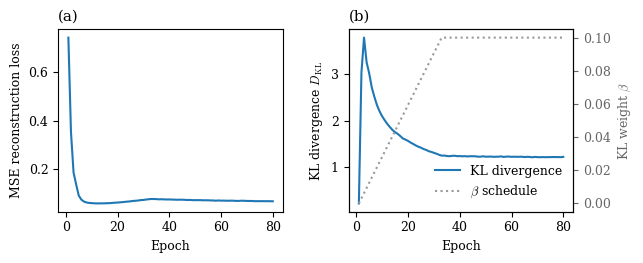

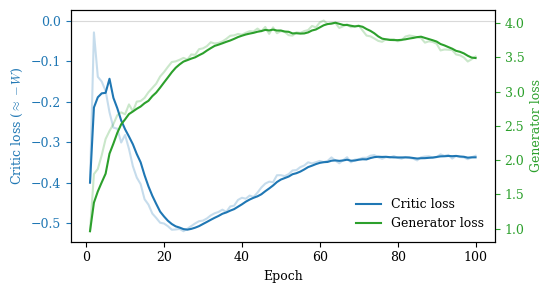

In [10]:
# ============================================================================
# Training curves for the appendix — replicates run_seed's main split, seed 111
# Fits ONLY the main generator (no shadows / no attack), then plots inline.
# ============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({"font.family": "serif", "mathtext.fontset": "cm", "font.size": 9})

SEED = 111
np.random.seed(SEED); torch.manual_seed(SEED)

# --- same user split as run_seed ---
user_summary = build_user_summary(
    df, user_col='user_id', duration_col='duration_minutes',
    distance_col='centroid_dist',
    test_size=TEST_SIZE, shadow_size=SHADOW_SIZE, random_state=SEED,
)
main_train_df = get_user_trips(df, get_main_training_users(user_summary))

pipeline = ODFeaturePipeline(); pipeline.fit(main_train_df)

# --- fit main generators through the wrapper, exactly as in run_seed ---
curve_hist = {}
for model_name in ['VAE', 'WGAN_GP']:
    model_cls, model_params, train_params = MODELS[model_name]
    mp, tp = seeded_params(model_params, train_params, SEED)
    main_gen = GeneratorWrapper(model_cls, mp, tp, pipeline)
    main_gen.fit(main_train_df)
    curve_hist[model_name] = main_gen.model.history

In [12]:

FIG_DIR = Path('outputs/figures'); FIG_DIR.mkdir(parents=True, exist_ok=True)

COLOURS = {'Bootstrap': '#d62728', 'VAE': '#1f77b4', 'WGAN_GP': '#2ca02c'}
MODEL_LABELS = {'VAE': 'VAE', 'WGAN_GP': 'WGAN-GP', 'Bootstrap': 'Bootstrap'}
def mlabel(m): return MODEL_LABELS.get(m, m.replace('_', '-'))

FPR_TARGETS = (0.01, 0.05, 0.10)
N_BOOT      = 2000

# ---- standardised plotting style (overridable per figure) ----
FONT_FAMILY   = 'DejaVu Sans'   # swap to 'serif' to match a serif LaTeX body
BASE_FONTSIZE = 11

mpl.rcParams.update({
    'figure.dpi':        110,
    'savefig.dpi':       200,
    'savefig.bbox':      'tight',
    'font.family':       FONT_FAMILY,
    'font.size':         BASE_FONTSIZE,
    'axes.titlesize':    BASE_FONTSIZE + 1,
    'axes.labelsize':    BASE_FONTSIZE,
    'xtick.labelsize':   BASE_FONTSIZE - 1,
    'ytick.labelsize':   BASE_FONTSIZE - 1,
    'legend.fontsize':   BASE_FONTSIZE - 1,
    'legend.frameon':    False,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'axes.grid.axis':    'y',      # horizontal gridlines only
    'axes.axisbelow':    True,
    'grid.alpha':        0.25,
    'grid.linewidth':    0.6,
    'errorbar.capsize':  4,
    'lines.markersize':  8,
    'svg.fonttype':      'none',   # keep SVG text editable / LaTeX-matchable
})

# standard sizes — pass size='wide' etc., or figsize=(w, h) to override
FIGSIZE = {'single': (6.0, 4.2), 'wide': (9.0, 4.2),
           'square': (5.6, 5.2), 'tall': (7.2, 6.0)}

def new_fig(size='single', figsize=None, **kw):
    '''fig, ax(es) at a standard size. Override with size= or figsize=.'''
    fs = figsize if figsize is not None else FIGSIZE.get(size, FIGSIZE['single'])
    return plt.subplots(figsize=fs, **kw)

def save_fig(fig, name, formats=('pdf',)):
    for ext in formats:
        fig.savefig(FIG_DIR / f'{name}.{ext}')
    print('saved:', ', '.join(f'{name}.{e}' for e in formats), '->', FIG_DIR)



saved: vae_training_curves.pdf -> outputs/figures


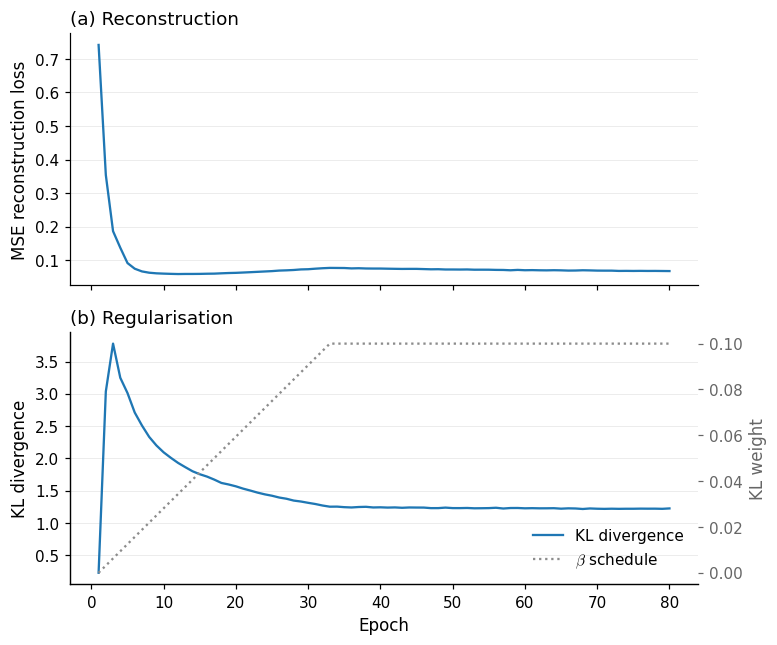

saved: wgan_training_curves.pdf -> outputs/figures


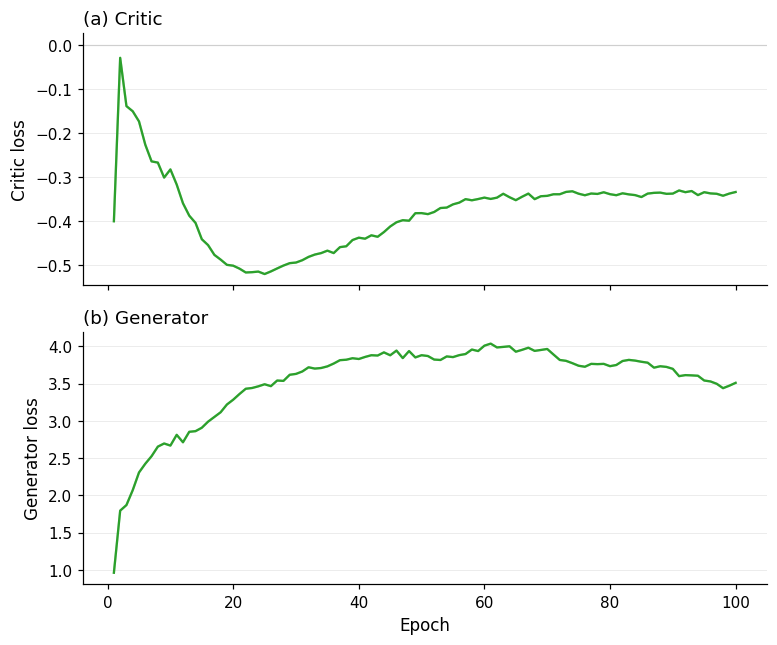

In [17]:
# ============================================================================
# Training curves (seed 111) — stacked panels, shared x-axis, house style.
# Reuses curve_hist from the earlier fit; no retraining.
# ============================================================================
ROLL = 1  # rolling window to read the trend through WGAN batch noise

# ----------------------------- VAE -----------------------------
h  = curve_hist['VAE']
ep = np.arange(1, len(h['recon']) + 1)

fig, (a, b) = new_fig(size='tall', nrows=2, sharex=True)

a.plot(ep, h['recon'], color=COLOURS['VAE'])
a.set_ylabel('MSE reconstruction loss')
a.set_title('(a) Reconstruction', loc='left')

b.plot(ep, h['kl'], color=COLOURS['VAE'], label='KL divergence')
b.set_xlabel('Epoch'); b.set_ylabel(r'KL divergence')
b.set_title('(b) Regularisation', loc='left')
bb = b.twinx()
bb.grid(False)
bb.plot(ep, h['beta'], color='0.55', ls=':', label=r'$\beta$ schedule')
bb.set_ylabel(r'KL weight', color='0.4'); bb.tick_params(axis='y', colors='0.4')
lines = b.get_lines() + bb.get_lines()
b.legend(lines, [l.get_label() for l in lines], loc='lower right')

fig.tight_layout(); save_fig(fig, 'vae_training_curves'); plt.show()

# --------------------------- WGAN-GP ---------------------------
h  = curve_hist['WGAN_GP']
ep = np.arange(1, len(h['c_loss']) + 1)
c  = pd.Series(h['c_loss']); g = pd.Series(h['g_loss'])

fig, (a, b) = new_fig(size='tall', nrows=2, sharex=True)

a.axhline(0, color='0.85', lw=0.8, zorder=0)
a.plot(ep, c, color=COLOURS['WGAN_GP'], alpha=0.25)
a.plot(ep, c.rolling(ROLL, min_periods=1).mean(), color=COLOURS['WGAN_GP'])
a.set_ylabel(r'Critic loss')
a.set_title('(a) Critic', loc='left')

b.plot(ep, g, color=COLOURS['WGAN_GP'], alpha=0.25)
b.plot(ep, g.rolling(ROLL, min_periods=1).mean(), color=COLOURS['WGAN_GP'])
b.set_xlabel('Epoch'); b.set_ylabel('Generator loss')
b.set_title('(b) Generator', loc='left')

fig.tight_layout(); save_fig(fig, 'wgan_training_curves'); plt.show()